# Dendrogram-aligned DGE marker heatmap

This notebook keeps the **cluster order fixed** to the leaf order of the SFUMATO dendrogram, so that neighbouring columns correspond to neighbouring dendrogram leaves / similar cluster colours.

The important change compared with the previous notebook is the marker selection:

- clusters are **not** reordered by the marker heatmap;
- candidate markers are still computed by one-vs-rest enrichment;
- genes are selected with a dendrogram-aware balanced strategy, favouring genes whose positive z-scored expression is concentrated in a local region of the fixed dendrogram axis;
- the selected genes are then ordered by the centre of mass of their positive signal along that axis.

This is designed to make a block-diagonal structure visible without changing the cluster order.

In [1]:
# If needed, install these in the environment where the notebook will be run:
# pip install anndata scanpy pandas numpy scipy matplotlib seaborn statsmodels

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy import sparse
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact

try:
    import anndata as ad
except ImportError as e:
    raise ImportError("Please install anndata or scanpy before running this notebook.") from e

try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    warnings.warn("statsmodels not available: adjusted p-values will be skipped.")

sns.set_theme(style="white", context="paper")

## 1. Configuration

Set the input path and column names here. Cluster order is fixed by `DENDROGRAM_CLUSTER_ORDER`.

Recommended first run:

```python
MARKER_SELECTION_MODE = "dendrogram_block_balanced"
TOP_N_MARKERS_TOTAL = 45
DENDROGRAM_SELECTION_BINS = 8
MAX_MARKERS_PER_DENDRO_BIN = 7
MAX_MARKERS_PER_BEST_CLUSTER = 2
```

`dendrogram_block_balanced` is not a per-cluster selection. It is a global marker panel selected to cover the dendrogram axis and favour local/block-like marker profiles.

In [2]:
# Input/output
ADATA_PATH = Path(r"full\newcolors\mousexeniumcell_BGM68to45_BIN7_F5_SVD10_FULL.h5ad")
OUTPUT_DIR = Path("./dge_cell_level_45_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Analysis mode
ASSIGNMENT_MODE = "thresholded"  # "thresholded", "hard_all", or future "weighted"
P1_THRESHOLD = 0.8

# Marker panel
TOP_N_MARKERS_TOTAL = 45
MARKER_SELECTION_MODE = "dendrogram_block_balanced"
# Options:
# - "dendrogram_block_balanced": recommended. Global panel, balanced along the fixed dendrogram axis.
# - "balanced_global": compact global panel with a cap per best cluster.
# - "global_top": top genes globally, no balancing. Can be dominated by a few clusters.
# - "per_cluster": K markers per cluster. Useful for atlas/QC, usually too many genes for the main figure.
MAX_MARKERS_PER_BEST_CLUSTER = 2
MARKERS_PER_CLUSTER = 2

# Dendrogram-aware selection parameters.
# Genes are assigned to bins according to the centre of mass of their positive z-scored signal
# along the fixed dendrogram order. This encourages coverage of the full left-to-right axis.
DENDROGRAM_SELECTION_BINS = 8
MAX_MARKERS_PER_DENDRO_BIN = 7
DENDROGRAM_COMPACTNESS_SCALE = 6.0  # smaller = stronger penalty for broad/non-local genes
MIN_POSITIVE_Z_MASS = 2.0
MIN_MAX_Z = 1.0

MIN_LOG2FC = 0.25
MIN_BEST_CLUSTER_FRACTION = 1e-5
MIN_SPECIFICITY = 0.05
PSEUDOCOUNT = 0.5

# Optional p-value calculation for the strongest candidate gene-cluster pairs.
# Set to 0 for a faster purely effect-size-based prototype.
COMPUTE_PVALUES_FOR_TOP_N_PAIRS = 3000

# Column names: fill these explicitly for your file.
CLUSTER_COL = "cluster"
GENE_COL = "target_name"
P1_COL = None
COMPL_P1_COL = "compl_p1"       # p1 = 1 - compl_p1
COLOR_COL = "color_hard_hsv"    # obsolete name; values are treated as hex/RGB strings
X_COL = "x"
Y_COL = "y"
SAMPLE_COL = None

# AnnData matrix mode settings, used only if genes are in adata.var and expression is in X/layer.
EXPRESSION_LAYER = None
USE_RAW_IF_AVAILABLE = False

# Dendrogram-aligned cluster order
# This is the left-to-right K=45 order from the shared dendrogram cut.
# Use strings without the C prefix; the code also accepts adata cluster labels like C0, C1, ...
DENDROGRAM_CLUSTER_ORDER = [
    "0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11",
    "12", "14", "13", "15", "16", "17", "18", "19", "20", "22", "21",
    "24", "23", "25", "26", "27", "28", "29", "30", "32", "31", "33",
    "34", "35", "37", "36", "38", "39", "40", "43", "42", "41", "44",
]

# Plot settings
FIG_DPI = 300
HEATMAP_CMAP = "vlag"
CLIP_Z = 2.8  # use None to disable clipping
SHOW_CLUSTER_LABELS = True
SHOW_COLOR_BAR_CLUSTER_LABELS = False
RANDOM_SEED = 7

np.random.seed(RANDOM_SEED)


## 2. Helper functions

In [3]:
def first_existing_column(df, candidates, explicit=None, required=False, label="column"):
    if explicit is not None:
        if explicit not in df.columns:
            raise KeyError(f"Requested {label} '{explicit}' was not found. Available columns include: {list(df.columns[:30])}")
        return explicit
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f"Could not infer {label}. Tried: {candidates}. Available columns include: {list(df.columns[:30])}")
    return None


def parse_color(value):
    # Return a valid hex color from common stored formats. color_hard_hsv is treated as stored hex/RGB despite the obsolete name.
    if pd.isna(value):
        return None
    if isinstance(value, str):
        text = value.strip()
        if text.startswith("#"):
            return text
        if text.startswith("(") and text.endswith(")"):
            try:
                vals = [float(x.strip()) for x in text.strip("()").split(",")]
                if len(vals) >= 3:
                    vals = vals[:3]
                    if max(vals) > 1:
                        vals = [v / 255 for v in vals]
                    return to_hex(vals)
            except Exception:
                pass
        try:
            return to_hex(to_rgb(text))
        except Exception:
            return None
    if isinstance(value, (tuple, list, np.ndarray)) and len(value) >= 3:
        vals = [float(v) for v in value[:3]]
        if max(vals) > 1:
            vals = [v / 255 for v in vals]
        return to_hex(vals)
    return None


def generated_cluster_colors(clusters):
    palette = sns.color_palette("husl", n_colors=len(clusters))
    return {cluster: to_hex(color) for cluster, color in zip(clusters, palette)}


def get_cluster_colors(obs, cluster_col, color_col, clusters):
    generated = generated_cluster_colors(clusters)
    if color_col is None or color_col not in obs.columns:
        return generated
    color_map = {}
    for cluster, group in obs[[cluster_col, color_col]].dropna().groupby(cluster_col):
        parsed = group[color_col].map(parse_color).dropna()
        if len(parsed) > 0:
            color_map[str(cluster)] = parsed.value_counts().idxmax()
    for cluster in clusters:
        color_map.setdefault(str(cluster), generated[str(cluster)])
    return color_map


def zscore_by_gene(df):
    z = df.copy().astype(float)
    z = z.subtract(z.mean(axis=0), axis=1)
    denom = z.std(axis=0).replace(0, np.nan)
    return z.divide(denom, axis=1).fillna(0)


def safe_linkage_order(matrix, axis=0, metric="correlation", method="average"):
    arr = np.asarray(matrix if axis == 0 else matrix.T, dtype=float)
    if arr.shape[0] <= 1:
        return list(range(arr.shape[0]))
    distances = pdist(np.nan_to_num(arr), metric=metric)
    if np.any(~np.isfinite(distances)) or len(distances) == 0:
        return list(range(arr.shape[0]))
    return leaves_list(linkage(distances, method=method)).tolist()


def benjamini_hochberg(pvals):
    pvals = np.asarray(pvals, dtype=float)
    if HAS_STATSMODELS:
        return multipletests(pvals, method="fdr_bh")[1]
    order = np.argsort(pvals)
    adjusted = np.empty_like(pvals)
    n = len(pvals)
    running = 1.0
    for rank, idx in enumerate(order[::-1], start=1):
        true_rank = n - rank + 1
        running = min(running, pvals[idx] * n / true_rank)
        adjusted[idx] = running
    return np.clip(adjusted, 0, 1)

## 3. Load the `.h5ad` and validate configured columns

Column names are defined explicitly in the configuration cell. This avoids silent mistakes caused by guessing column names.


In [4]:
if not ADATA_PATH.exists():
    raise FileNotFoundError(
        f"Set ADATA_PATH before running the notebook. Current value does not exist: {ADATA_PATH}"
    )

adata = ad.read_h5ad(ADATA_PATH)
print(adata)
print("obs columns:", list(adata.obs.columns[:80]))
print("var columns:", list(adata.var.columns[:40]))

AnnData object with n_obs × n_vars = 42196646 × 0
    obs: 'x', 'y', 'target_name', 'bin_id', 'cluster', 'second_cluster', 'color_hard_hsv', 'color_log_hsv', 'compl_p1', 'mix_t', 'cmap_pos', 'cluster_p2r', 'color_p2r'
obs columns: ['x', 'y', 'target_name', 'bin_id', 'cluster', 'second_cluster', 'color_hard_hsv', 'color_log_hsv', 'compl_p1', 'mix_t', 'cmap_pos', 'cluster_p2r', 'color_p2r']
var columns: []


In [5]:
def require_obs_column(adata, col, label, allow_none=False):
    if col is None and allow_none:
        return None
    if col is None:
        raise ValueError(f"Please set {label} in the configuration cell.")
    if col not in adata.obs.columns:
        raise KeyError(
            f"Configured {label}='{col}' was not found in adata.obs. "
            f"Available columns include: {list(adata.obs.columns[:80])}"
        )
    return col

cluster_col = require_obs_column(adata, CLUSTER_COL, "CLUSTER_COL")
gene_col = require_obs_column(adata, GENE_COL, "GENE_COL", allow_none=True)
p1_col = require_obs_column(adata, P1_COL, "P1_COL", allow_none=True)
compl_p1_col = require_obs_column(adata, COMPL_P1_COL, "COMPL_P1_COL", allow_none=True)
color_col = require_obs_column(adata, COLOR_COL, "COLOR_COL", allow_none=True)
x_col = require_obs_column(adata, X_COL, "X_COL", allow_none=True)
y_col = require_obs_column(adata, Y_COL, "Y_COL", allow_none=True)
sample_col = require_obs_column(adata, SAMPLE_COL, "SAMPLE_COL", allow_none=True)

if p1_col is None and compl_p1_col is None and ASSIGNMENT_MODE == "thresholded":
    raise ValueError("Thresholded mode requires either P1_COL or COMPL_P1_COL.")

print("Using cluster_col:", cluster_col)
print("Using gene_col:", gene_col)
print("Using p1_col:", p1_col)
print("Using compl_p1_col:", compl_p1_col)
print("Using color_col:", color_col)
print("Using x/y columns:", x_col, y_col)
print("Using sample_col:", sample_col)


Using cluster_col: cluster
Using gene_col: target_name
Using p1_col: None
Using compl_p1_col: compl_p1
Using color_col: color_hard_hsv
Using x/y columns: x y
Using sample_col: None


## 4. Apply assignment mode

For this prototype the intended mode is `thresholded`: keep only observations with `p1 >= P1_THRESHOLD`. If only `compl_p1` is present, `p1` is computed as `1 - compl_p1`.

In [6]:
obs = adata.obs.copy()

if p1_col is not None:
    p1 = pd.to_numeric(obs[p1_col], errors="coerce")
elif compl_p1_col is not None:
    p1 = 1 - pd.to_numeric(obs[compl_p1_col], errors="coerce")
else:
    p1 = pd.Series(np.nan, index=obs.index)
    warnings.warn("No p1 or complementary p1 column found. Thresholding will be skipped unless a column is specified.")

obs["_p1_for_marker_analysis"] = p1

if ASSIGNMENT_MODE == "thresholded":
    if obs["_p1_for_marker_analysis"].notna().any():
        keep_mask = obs["_p1_for_marker_analysis"] >= P1_THRESHOLD
    else:
        keep_mask = pd.Series(True, index=obs.index)
        warnings.warn("No usable probability column was found; keeping all observations.")
    weights = pd.Series(1.0, index=obs.index)
elif ASSIGNMENT_MODE == "hard_all":
    keep_mask = pd.Series(True, index=obs.index)
    weights = pd.Series(1.0, index=obs.index)
elif ASSIGNMENT_MODE == "weighted":
    raise NotImplementedError(
        "Weighted mode is reserved for the final run with the full transcript-level probability table. "
        "For now use ASSIGNMENT_MODE='thresholded' or 'hard_all'."
    )
else:
    raise ValueError(f"Unknown ASSIGNMENT_MODE: {ASSIGNMENT_MODE}")

obs_keep = obs.loc[keep_mask].copy()
weights_keep = weights.loc[obs_keep.index]

print(f"Assignment mode: {ASSIGNMENT_MODE}")
print(f"Kept observations: {obs_keep.shape[0]:,} / {obs.shape[0]:,} ({obs_keep.shape[0] / obs.shape[0]:.1%})")
print(f"Number of clusters after filtering: {obs_keep[cluster_col].nunique()}")

Assignment mode: thresholded
Kept observations: 33,666,798 / 42,196,646 (79.8%)
Number of clusters after filtering: 45


## 5. Build cluster × gene expression profiles

Two input structures are supported:
1. transcript-table-like `.h5ad`, where genes are stored in `adata.obs[gene_col]`;
2. standard AnnData matrix, where genes are stored in `adata.var_names` and expression is in `adata.X`, a selected layer, or `adata.raw`.

In [7]:
def build_expression_from_obs_table(obs_keep, weights_keep, cluster_col, gene_col):
    if gene_col is None:
        raise ValueError("gene_col is required for transcript-table-like input.")
    tmp = pd.DataFrame({
        "cluster": obs_keep[cluster_col].astype(str).values,
        "gene": obs_keep[gene_col].astype(str).values,
        "weight": weights_keep.astype(float).values,
    }).dropna(subset=["cluster", "gene"])
    counts = tmp.pivot_table(index="cluster", columns="gene", values="weight", aggfunc="sum", fill_value=0)
    return counts.sort_index(axis=0).sort_index(axis=1)


def build_expression_from_anndata_matrix(adata, obs_keep, cluster_col, layer=None, use_raw=False):
    if use_raw and adata.raw is not None:
        X = adata.raw.X
        var_names = adata.raw.var_names.astype(str)
        obs_indexer = adata.obs_names.get_indexer(obs_keep.index)
        X = X[obs_indexer, :]
    else:
        X = adata.layers[layer] if layer is not None else adata.X
        var_names = adata.var_names.astype(str)
        obs_indexer = adata.obs_names.get_indexer(obs_keep.index)
        X = X[obs_indexer, :]

    clusters_local = obs_keep[cluster_col].astype(str).values
    cluster_categories = pd.Index(sorted(pd.unique(clusters_local)))
    rows = []
    for cluster in cluster_categories:
        idx = np.where(clusters_local == cluster)[0]
        sub = X[idx, :]
        summed = np.asarray(sub.sum(axis=0)).ravel() if sparse.issparse(sub) else np.asarray(sub).sum(axis=0)
        rows.append(summed)
    return pd.DataFrame(rows, index=cluster_categories, columns=var_names)

if gene_col is not None:
    input_structure = "obs_table"
    counts_cluster_gene = build_expression_from_obs_table(obs_keep, weights_keep, cluster_col, gene_col)
else:
    input_structure = "anndata_matrix"
    counts_cluster_gene = build_expression_from_anndata_matrix(
        adata, obs_keep, cluster_col, layer=EXPRESSION_LAYER, use_raw=USE_RAW_IF_AVAILABLE
    )

counts_cluster_gene = counts_cluster_gene.loc[counts_cluster_gene.sum(axis=1) > 0, counts_cluster_gene.sum(axis=0) > 0]
cluster_totals = counts_cluster_gene.sum(axis=1)
gene_totals = counts_cluster_gene.sum(axis=0)

cpm_cluster_gene = counts_cluster_gene.div(cluster_totals, axis=0) * 1e6
log_cpm_cluster_gene = np.log1p(cpm_cluster_gene)
clusters = counts_cluster_gene.index.astype(str).tolist()

print("Input structure:", input_structure)
print("Cluster × gene matrix:", counts_cluster_gene.shape)
display(cluster_totals.describe())

Input structure: obs_table
Cluster × gene matrix: (45, 248)


count    4.500000e+01
mean     7.481511e+05
std      9.156601e+05
min      5.940600e+04
25%      2.037530e+05
50%      3.855720e+05
75%      7.501050e+05
max      4.524042e+06
dtype: float64

## 6. Differential enrichment / marker ranking

This section computes one-vs-rest enrichment for every cluster.

The default final selection is **not per cluster**. It is `dendrogram_block_balanced`: a compact global panel that prefers genes with a local positive signal along the fixed dendrogram order and balances the selected genes across the dendrogram axis. This is meant to preserve a block/diagonal structure while keeping the cluster order fixed.

In [8]:
def compute_marker_candidates(counts, pseudocount=0.5):
    counts = counts.astype(float)
    cluster_totals_local = counts.sum(axis=1)
    gene_totals_local = counts.sum(axis=0)
    total = float(cluster_totals_local.sum())
    n_genes = counts.shape[1]
    rows = []

    gene_profile = counts.div(cluster_totals_local.replace(0, np.nan), axis=0).fillna(0)
    specificity = gene_profile.div(gene_profile.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)

    for cluster in counts.index:
        a = counts.loc[cluster]
        cluster_total = float(cluster_totals_local.loc[cluster])
        rest_gene = gene_totals_local - a
        rest_total = total - cluster_total
        rate_cluster = (a + pseudocount) / (cluster_total + pseudocount * n_genes)
        rate_rest = (rest_gene + pseudocount) / (rest_total + pseudocount * n_genes)
        log2fc = np.log2(rate_cluster / rate_rest)
        best_cluster_fraction = a / max(cluster_total, 1)
        spec = specificity.loc[cluster]
        rows.append(pd.DataFrame({
            "gene": counts.columns.astype(str),
            "cluster": str(cluster),
            "count_in_cluster": a.values,
            "count_in_rest": rest_gene.values,
            "cluster_total": cluster_total,
            "rest_total": rest_total,
            "log2fc": log2fc.values,
            "best_cluster_fraction": best_cluster_fraction.values,
            "specificity": spec.values,
        }))

    pairs = pd.concat(rows, ignore_index=True)
    pairs["effect_score"] = (
        pairs["log2fc"].clip(lower=0)
        * np.sqrt(pairs["specificity"].clip(lower=0))
        * np.log1p(pairs["count_in_cluster"])
    )
    return pairs

marker_pairs = compute_marker_candidates(counts_cluster_gene, pseudocount=PSEUDOCOUNT)

candidate_mask = (
    (marker_pairs["log2fc"] >= MIN_LOG2FC)
    & (marker_pairs["best_cluster_fraction"] >= MIN_BEST_CLUSTER_FRACTION)
    & (marker_pairs["specificity"] >= MIN_SPECIFICITY)
)
marker_pairs_filtered = marker_pairs.loc[candidate_mask].copy()

print("Candidate gene-cluster pairs:", marker_pairs_filtered.shape)
display(marker_pairs_filtered.sort_values("effect_score", ascending=False).head(10))

Candidate gene-cluster pairs: (1182, 10)


,gene,cluster,count_in_cluster,count_in_rest,cluster_total,rest_total,log2fc,best_cluster_fraction,specificity,effect_score
5177,Spag16,27,5346.0,5819.0,251387.0,33415411.0,6.931453,0.021266,0.694379,49.582333
7695,Aldh1a2,37,11761.0,29191.0,324072.0,33342726.0,5.372891,0.036291,0.517098,36.212280
7766,Fmod,37,12561.0,30909.0,324072.0,33342726.0,5.385326,0.038760,0.503493,36.066863
7031,Gfap,34,22819.0,232010.0,59406.0,33607392.0,5.795100,0.384119,0.323313,33.067943
2627,Opalin,18,67806.0,85162.0,750105.0,32916693.0,5.126555,0.090395,0.334634,32.990442
7484,Cldn5,36,80028.0,47711.0,1330309.0,32336489.0,5.349378,0.060157,0.279354,31.921258
5163,Slc13a4,27,11445.0,37987.0,251387.0,33415411.0,5.323009,0.045527,0.401226,31.510079
7751,Dcn,37,15071.0,51530.0,324072.0,33342726.0,4.910764,0.046505,0.411968,30.323749
7656,Sox17,36,18414.0,9926.0,1330309.0,32336489.0,5.494686,0.013842,0.315458,30.308608
7739,Col1a1,37,9343.0,29181.0,324072.0,33342726.0,5.041348,0.028830,0.423804,30.004995


In [9]:
marker_pairs_filtered["p_value"] = np.nan
marker_pairs_filtered["adj_p_value"] = np.nan

if COMPUTE_PVALUES_FOR_TOP_N_PAIRS and COMPUTE_PVALUES_FOR_TOP_N_PAIRS > 0:
    top_idx = marker_pairs_filtered.sort_values("effect_score", ascending=False).head(COMPUTE_PVALUES_FOR_TOP_N_PAIRS).index
    pvals = []
    for idx in top_idx:
        row = marker_pairs_filtered.loc[idx]
        a = int(round(row["count_in_cluster"]))
        b = int(round(row["cluster_total"] - row["count_in_cluster"]))
        c = int(round(row["count_in_rest"]))
        d = int(round(row["rest_total"] - row["count_in_rest"]))
        _, p = fisher_exact([[a, b], [c, d]], alternative="greater")
        pvals.append(p)
    marker_pairs_filtered.loc[top_idx, "p_value"] = pvals
    marker_pairs_filtered.loc[top_idx, "adj_p_value"] = benjamini_hochberg(pvals)

marker_pairs_filtered["minus_log10_adj_p"] = -np.log10(marker_pairs_filtered["adj_p_value"].clip(lower=1e-300))
marker_pairs_filtered["minus_log10_adj_p"] = marker_pairs_filtered["minus_log10_adj_p"].replace([np.inf, -np.inf], np.nan).fillna(0)
marker_pairs_filtered["ranking_score"] = marker_pairs_filtered["effect_score"] * (1 + np.log1p(marker_pairs_filtered["minus_log10_adj_p"]))

gene_best = (
    marker_pairs_filtered.sort_values("ranking_score", ascending=False)
    .drop_duplicates("gene", keep="first")
    .sort_values("ranking_score", ascending=False)
    .reset_index(drop=True)
)


def canonical_cluster_label(x):
    """Normalize cluster labels so C17, 17, and 17.0 can match."""
    s = str(x).strip()
    if s.startswith("C") and s[1:].isdigit():
        s = s[1:]
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return s


def resolve_dendrogram_order(available_clusters, dendrogram_order):
    available_clusters = [str(c) for c in available_clusters]
    available_by_canonical = {canonical_cluster_label(c): c for c in available_clusters}
    ordered = []
    missing = []
    for c in dendrogram_order:
        key = canonical_cluster_label(c)
        if key in available_by_canonical:
            ordered.append(available_by_canonical[key])
        else:
            missing.append(str(c))
    used = set(ordered)
    extra = [c for c in available_clusters if c not in used]
    if extra:
        warnings.warn("Clusters absent from DENDROGRAM_CLUSTER_ORDER were appended: " + ", ".join(extra))
        ordered.extend(extra)
    if missing:
        warnings.warn("DENDROGRAM_CLUSTER_ORDER entries absent from data were skipped: " + ", ".join(missing))
    return ordered


def add_dendrogram_gene_metrics(gene_table, log_cpm, ordered_clusters):
    """Add centre-of-mass and compactness metrics for each gene along fixed dendrogram order."""
    genes = [g for g in gene_table["gene"].astype(str).tolist() if g in log_cpm.columns]
    heat = log_cpm.loc[ordered_clusters, genes]
    heat_z_all = zscore_by_gene(heat)
    gene_by_cluster = heat_z_all.T
    positive = gene_by_cluster.clip(lower=0)
    xpos = np.arange(len(ordered_clusters), dtype=float)

    pos_mass = positive.sum(axis=1)
    has_pos = pos_mass > 0
    center = pd.Series(np.nan, index=gene_by_cluster.index, dtype=float)
    center.loc[has_pos] = (positive.loc[has_pos].values @ xpos) / pos_mass.loc[has_pos].values

    best_cluster = gene_by_cluster.idxmax(axis=1)
    cluster_position = {cluster: i for i, cluster in enumerate(ordered_clusters)}
    best_pos = best_cluster.map(cluster_position).astype(float)
    center.loc[~has_pos] = best_pos.loc[~has_pos]

    width = pd.Series(np.nan, index=gene_by_cluster.index, dtype=float)
    for gene in gene_by_cluster.index:
        w = positive.loc[gene].values
        if w.sum() > 0:
            mu = center.loc[gene]
            width.loc[gene] = np.sqrt(np.sum(w * (xpos - mu) ** 2) / np.sum(w))
        else:
            width.loc[gene] = np.inf

    max_z = gene_by_cluster.max(axis=1)
    n_positive_clusters = (gene_by_cluster > 0).sum(axis=1)
    peak_minus_center = (best_pos - center).abs()

    metrics = pd.DataFrame({
        "gene": gene_by_cluster.index,
        "dendrogram_center_of_mass": center,
        "dendrogram_width": width,
        "dendrogram_best_cluster": best_cluster,
        "dendrogram_best_cluster_position": best_pos,
        "positive_z_mass": pos_mass,
        "max_z": max_z,
        "n_positive_clusters": n_positive_clusters,
        "peak_minus_center": peak_minus_center,
    }).reset_index(drop=True)

    out = gene_table.merge(metrics, on="gene", how="left")
    n = max(len(ordered_clusters), 1)
    bins = np.linspace(0, n, DENDROGRAM_SELECTION_BINS + 1)
    out["dendrogram_bin"] = np.digitize(out["dendrogram_center_of_mass"].clip(0, n - 1e-6), bins[1:-1]) + 1
    compactness = 1.0 / (1.0 + out["dendrogram_width"].fillna(n) / DENDROGRAM_COMPACTNESS_SCALE)
    signal = np.log1p(out["positive_z_mass"].fillna(0)) * out["max_z"].clip(lower=0).fillna(0)
    out["dendrogram_block_score"] = out["ranking_score"] * compactness * (1.0 + signal)
    return out


def select_marker_panel(gene_best, marker_pairs_filtered, mode="dendrogram_block_balanced", top_n=40):
    if mode == "global_top":
        return gene_best.head(top_n).copy().reset_index(drop=True)

    if mode == "per_cluster":
        per_cluster_rows = []
        for cluster, group in marker_pairs_filtered.sort_values("ranking_score", ascending=False).groupby("cluster", sort=False):
            per_cluster_rows.append(group.head(MARKERS_PER_CLUSTER))
        selected = pd.concat(per_cluster_rows, ignore_index=True)
        selected = selected.sort_values("ranking_score", ascending=False).drop_duplicates("gene", keep="first")
        return selected.reset_index(drop=True)

    if mode == "balanced_global":
        selected = []
        per_cluster = {}
        for _, row in gene_best.iterrows():
            cluster = row["cluster"]
            if per_cluster.get(cluster, 0) >= MAX_MARKERS_PER_BEST_CLUSTER:
                continue
            selected.append(row)
            per_cluster[cluster] = per_cluster.get(cluster, 0) + 1
            if len(selected) >= top_n:
                break
        if len(selected) < top_n:
            selected_genes_local = {row["gene"] for row in selected}
            for _, row in gene_best.iterrows():
                if row["gene"] in selected_genes_local:
                    continue
                selected.append(row)
                selected_genes_local.add(row["gene"])
                if len(selected) >= top_n:
                    break
        return pd.DataFrame(selected).reset_index(drop=True)

    if mode != "dendrogram_block_balanced":
        raise ValueError(f"Unknown MARKER_SELECTION_MODE: {mode}")

    ordered_clusters_for_selection = resolve_dendrogram_order(counts_cluster_gene.index.astype(str).tolist(), DENDROGRAM_CLUSTER_ORDER)
    scored = add_dendrogram_gene_metrics(gene_best, log_cpm_cluster_gene, ordered_clusters_for_selection)
    scored = scored[
        (scored["positive_z_mass"] >= MIN_POSITIVE_Z_MASS)
        & (scored["max_z"] >= MIN_MAX_Z)
    ].copy()
    scored = scored.sort_values("dendrogram_block_score", ascending=False)

    selected = []
    selected_genes_local = set()
    per_cluster = {}
    per_bin = {}

    # First pass: strict balancing by best cluster and dendrogram bin.
    for _, row in scored.iterrows():
        gene = row["gene"]
        cluster = row["cluster"]
        bin_id = int(row["dendrogram_bin"])
        if gene in selected_genes_local:
            continue
        if per_cluster.get(cluster, 0) >= MAX_MARKERS_PER_BEST_CLUSTER:
            continue
        if per_bin.get(bin_id, 0) >= MAX_MARKERS_PER_DENDRO_BIN:
            continue
        selected.append(row)
        selected_genes_local.add(gene)
        per_cluster[cluster] = per_cluster.get(cluster, 0) + 1
        per_bin[bin_id] = per_bin.get(bin_id, 0) + 1
        if len(selected) >= top_n:
            break

    # Second pass: relax the dendrogram-bin cap, keep cluster cap.
    if len(selected) < top_n:
        for _, row in scored.iterrows():
            gene = row["gene"]
            cluster = row["cluster"]
            if gene in selected_genes_local:
                continue
            if per_cluster.get(cluster, 0) >= MAX_MARKERS_PER_BEST_CLUSTER:
                continue
            selected.append(row)
            selected_genes_local.add(gene)
            per_cluster[cluster] = per_cluster.get(cluster, 0) + 1
            if len(selected) >= top_n:
                break

    # Final pass: fill remaining slots if needed.
    if len(selected) < top_n:
        for _, row in scored.iterrows():
            gene = row["gene"]
            if gene in selected_genes_local:
                continue
            selected.append(row)
            selected_genes_local.add(gene)
            if len(selected) >= top_n:
                break

    return pd.DataFrame(selected).reset_index(drop=True)


selected_markers = select_marker_panel(
    gene_best,
    marker_pairs_filtered,
    mode=MARKER_SELECTION_MODE,
    top_n=TOP_N_MARKERS_TOTAL,
)
selected_genes = selected_markers["gene"].astype(str).tolist()

panel_label = f"{MARKER_SELECTION_MODE}_{len(selected_genes)}_markers"
selected_markers_path = OUTPUT_DIR / f"selected_{panel_label}.csv"
all_candidates_path = OUTPUT_DIR / "all_marker_candidates.csv"
selected_markers.to_csv(selected_markers_path, index=False)
marker_pairs_filtered.sort_values("ranking_score", ascending=False).to_csv(all_candidates_path, index=False)

print("Marker selection mode:", MARKER_SELECTION_MODE)
print("Selected genes:")
print(selected_genes)
print("Markers per best cluster:")
display(selected_markers.groupby("cluster").size().rename("n_selected"))
if "dendrogram_bin" in selected_markers.columns:
    print("Markers per dendrogram bin:")
    display(selected_markers.groupby("dendrogram_bin").size().rename("n_selected"))
print("Saved:", selected_markers_path)
print("Saved:", all_candidates_path)
display(selected_markers)


Marker selection mode: dendrogram_block_balanced
Selected genes:
['Spag16', 'Aldh1a2', 'Fmod', 'Slc13a4', 'Acta2', 'Opalin', 'Gpr17', 'Sox17', 'Cspg4', 'Sox10', 'Vwc2l', 'Penk', 'Gfap', 'Ppp1r1b', 'Cabp7', 'Neurod6', 'Opn3', 'Cbln1', 'Nxph3', 'Slc17a6', 'Rspo1', 'Myl4', 'Chat', 'Rxfp1', 'Chodl', 'Pthlh', 'Arc', 'Gm2115', 'Bhlhe22', 'Prdm8', 'Satb2', 'Rasl10a', 'Sst', 'Cort', 'Unc13c', 'Cd44', 'Carmn', 'Slc39a12', 'Lamp5', 'Trem2', 'Siglech', 'Rfx4', 'Cd300c2', 'Ikzf1', 'Igfbp5']
Markers per best cluster:


cluster
1     2
10    1
11    2
12    1
13    2
15    1
17    2
18    2
23    2
26    2
27    2
30    1
31    2
33    1
34    2
35    2
36    2
37    2
39    2
4     2
40    2
41    2
42    2
44    2
5     2
Name: n_selected, dtype: int64

Markers per dendrogram bin:


dendrogram_bin
2     1
3     7
4     9
5    14
6    11
7     3
Name: n_selected, dtype: int64

Saved: dge_cell_level_45_outputs\selected_dendrogram_block_balanced_45_markers.csv
Saved: dge_cell_level_45_outputs\all_marker_candidates.csv


,gene,cluster,count_in_cluster,count_in_rest,cluster_total,rest_total,log2fc,best_cluster_fraction,specificity,effect_score,...,dendrogram_center_of_mass,dendrogram_width,dendrogram_best_cluster,dendrogram_best_cluster_position,positive_z_mass,max_z,n_positive_clusters,peak_minus_center,dendrogram_bin,dendrogram_block_score
0,Spag16,27,5346.0,5819.0,251387.0,33415411.0,6.931453,0.021266,0.694379,49.582333,...,29.835069,7.808926,27,27.0,15.371017,4.227261,20,2.835069,6,1852.048455
1,Aldh1a2,37,11761.0,29191.0,324072.0,33342726.0,5.372891,0.036291,0.517098,36.212280,...,32.561398,6.406774,37,36.0,16.110575,3.363258,15,3.438602,6,1239.259459
2,Fmod,37,12561.0,30909.0,324072.0,33342726.0,5.385326,0.038760,0.503493,36.066863,...,32.117537,6.831389,37,36.0,15.259501,3.429476,14,3.882463,6,1194.916400
3,Slc13a4,27,11445.0,37987.0,251387.0,33415411.0,5.323009,0.045527,0.401226,31.510079,...,30.935630,7.177347,27,27.0,15.626981,3.247198,13,3.935630,6,974.608436
4,Acta2,36,26230.0,26411.0,1330309.0,32336489.0,4.593280,0.019717,0.292457,25.274105,...,32.099405,5.652551,36,37.0,14.776604,3.552937,12,4.900595,6,942.758624
5,Opalin,18,67806.0,85162.0,750105.0,32916693.0,5.126555,0.090395,0.334634,32.990442,...,20.842034,6.622610,18,18.0,16.337846,2.698429,17,2.842034,4,914.874164
6,Gpr17,17,18617.0,44353.0,511182.0,33155616.0,4.766539,0.036420,0.307701,25.995856,...,21.185444,6.018459,17,17.0,16.181250,3.094586,14,4.185444,4,853.075906
7,Sox17,36,18414.0,9926.0,1330309.0,32336489.0,5.494686,0.013842,0.315458,30.308608,...,30.938627,7.766277,36,37.0,17.326973,2.699526,13,6.061373,6,784.223627
8,Cspg4,17,13907.0,28207.0,511182.0,33155616.0,4.998712,0.027206,0.359132,28.578768,...,25.648951,8.184266,17,17.0,18.596811,2.904283,17,8.648951,5,781.734449
9,Sox10,18,51372.0,89187.0,750105.0,32916693.0,4.659505,0.068486,0.272851,26.400182,...,20.402488,5.588356,18,18.0,15.558633,2.661814,15,2.402488,4,776.658869


## 7. Dendrogram-aligned marker heatmap

Columns are fixed by `DENDROGRAM_CLUSTER_ORDER`. Genes are ordered by the centre of mass of their positive z-scored expression along the same fixed axis.

This means that genes marking left dendrogram leaves appear near the top, genes marking central leaves in the middle, and genes marking right leaves near the bottom. If marker programs follow the dendrogram, the heatmap should become block-diagonal while preserving the original cluster order.

C:\Users\alegi784\AppData\Local\Temp\ipykernel_15640\1575569687.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, group in obs[[cluster_col, color_col]].dropna().groupby(cluster_col):


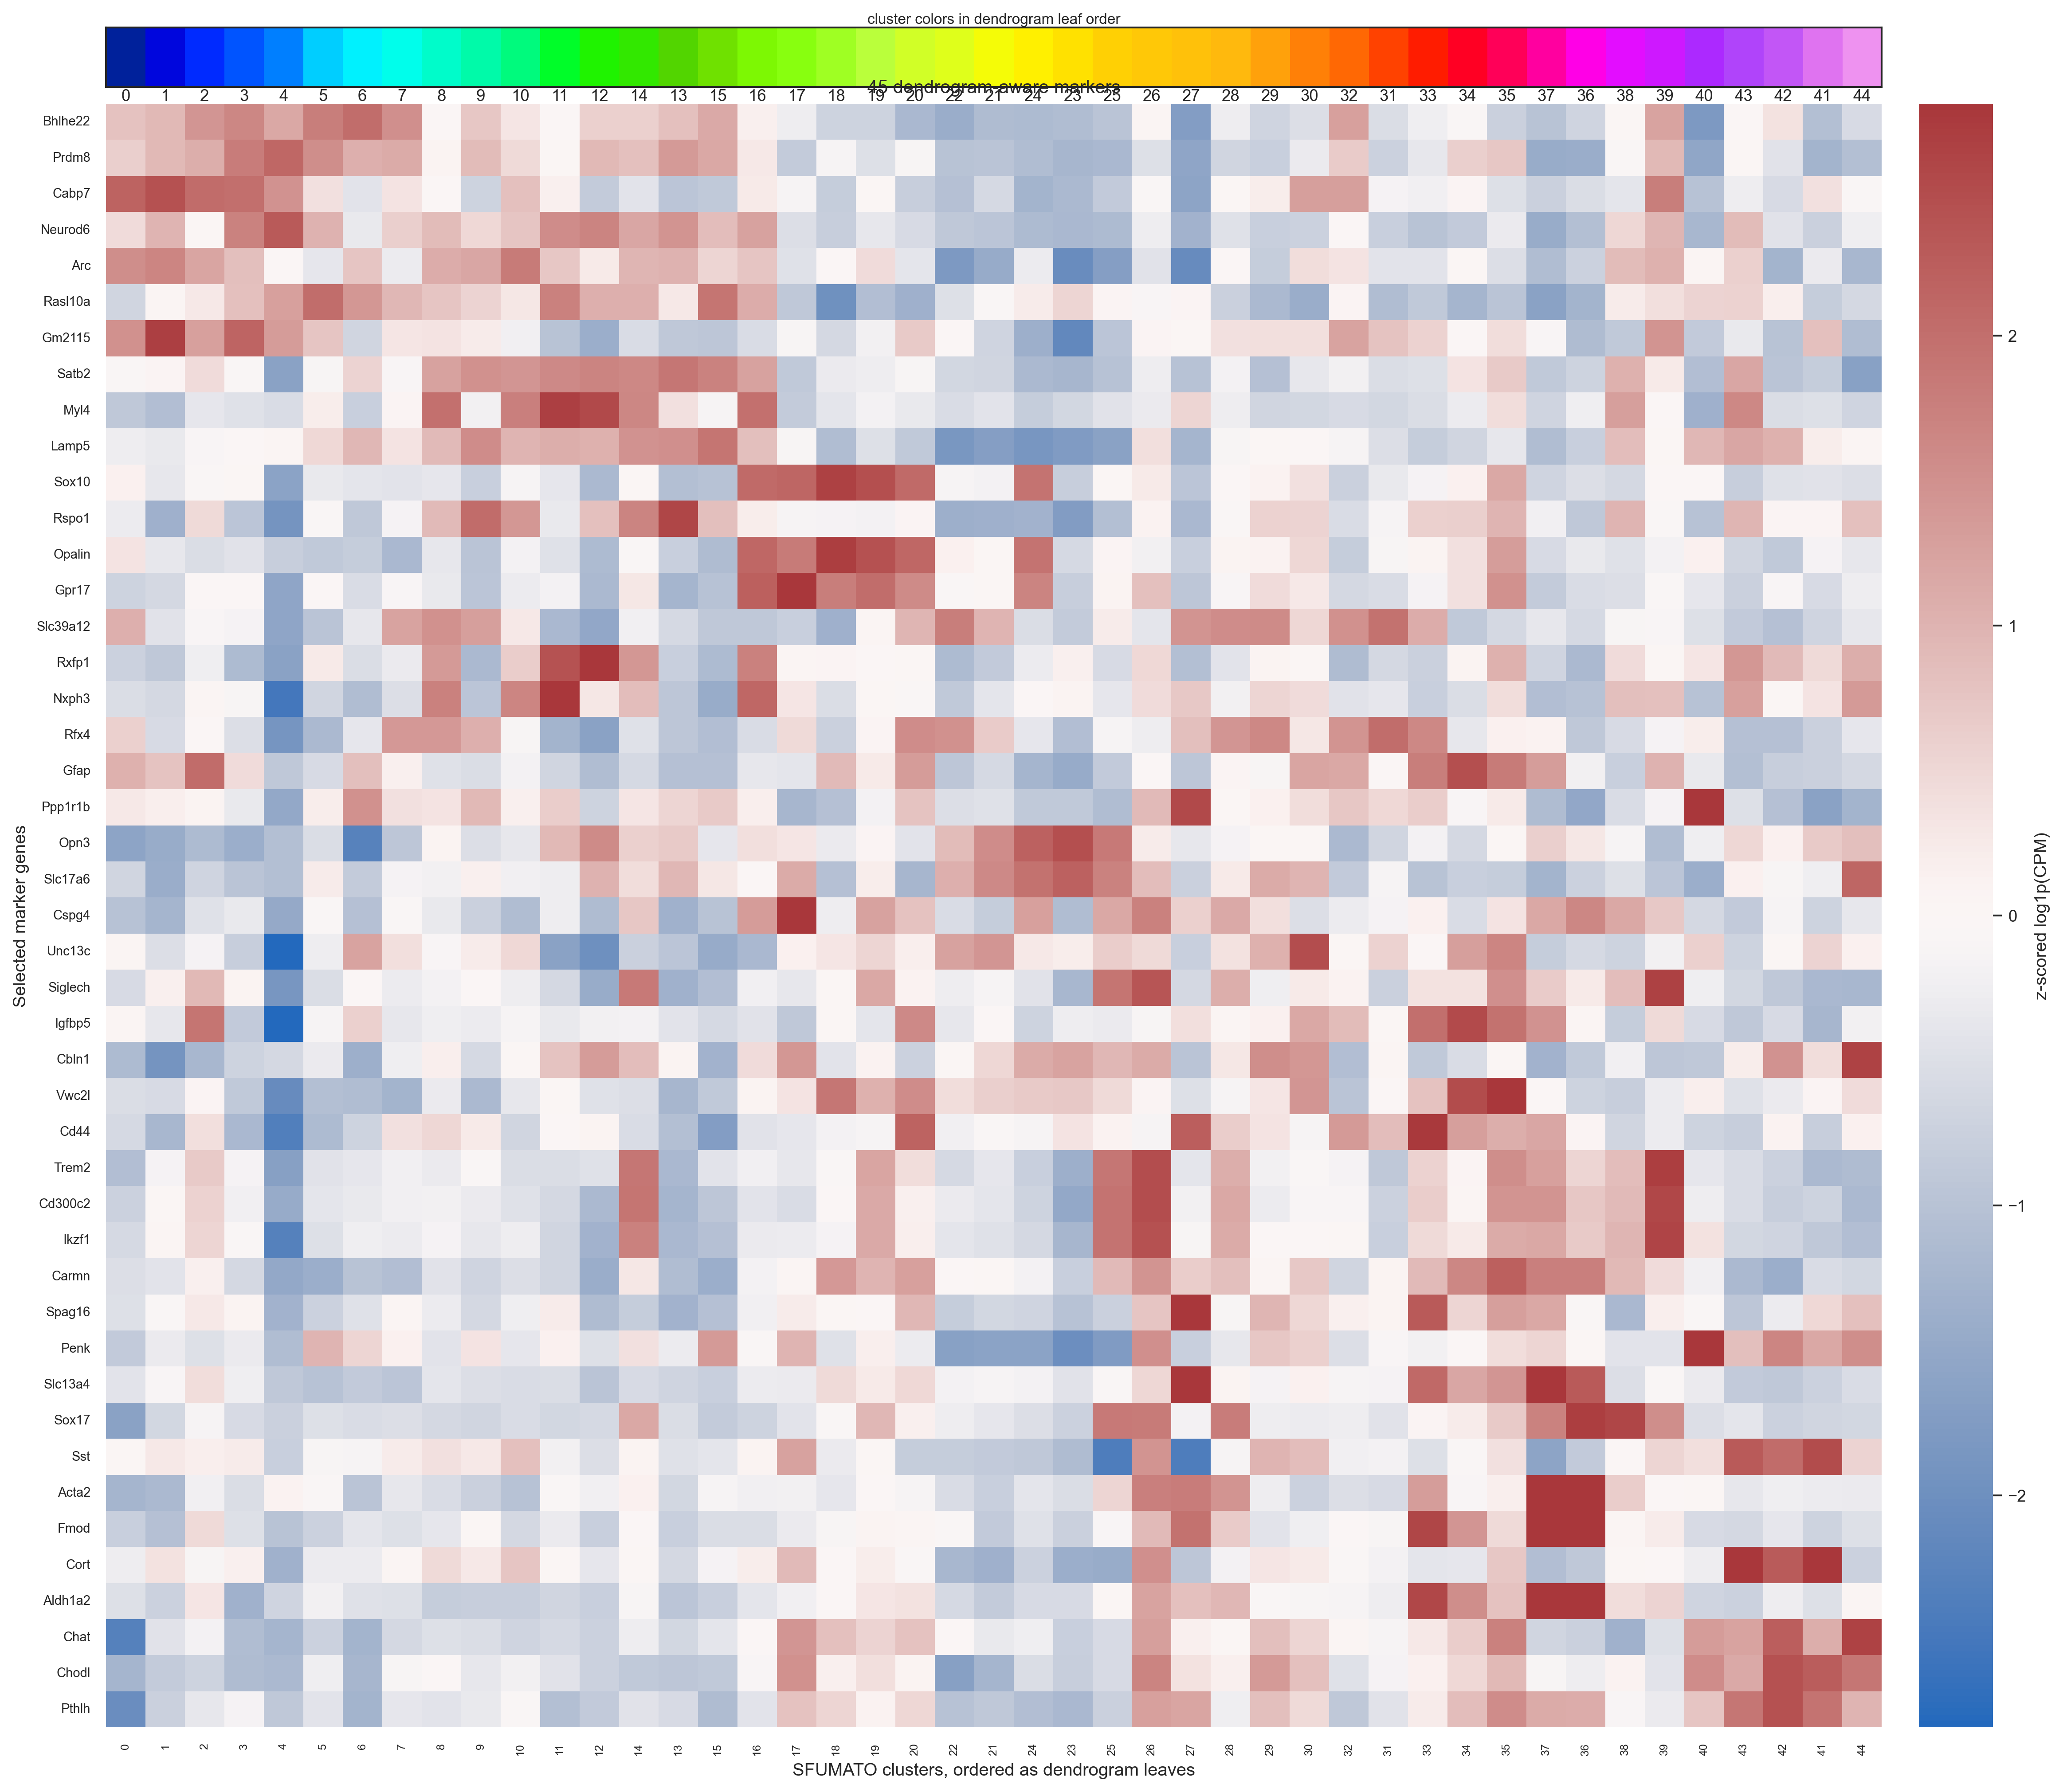

Dendrogram-ordered clusters: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '14', '13', '15', '16', '17', '18', '19', '20', '22', '21', '24', '23', '25', '26', '27', '28', '29', '30', '32', '31', '33', '34', '35', '37', '36', '38', '39', '40', '43', '42', '41', '44']
Saved: dge_cell_level_45_outputs\heatmap_genes_by_clusters_dendrogram_block_balanced_45_markers_dendrogram_aligned.png
Saved: dge_cell_level_45_outputs\heatmap_genes_by_clusters_dendrogram_block_balanced_45_markers_dendrogram_aligned.pdf
Saved: dge_cell_level_45_outputs\gene_order_dendrogram_block_balanced_45_markers_dendrogram_aligned.csv


In [10]:
if len(selected_genes) == 0:
    raise ValueError("No markers were selected. Relax filters or check the input columns.")

# ---------------------------------------------------------------------
# 1) Force the x-axis to follow the dendrogram leaf order.
# ---------------------------------------------------------------------
ordered_clusters = resolve_dendrogram_order(log_cpm_cluster_gene.index.astype(str).tolist(), DENDROGRAM_CLUSTER_ORDER)

# ---------------------------------------------------------------------
# 2) Order genes by where their positive signal lies along the dendrogram.
#    Use selected_markers metrics if available; otherwise compute them here.
# ---------------------------------------------------------------------
if {"dendrogram_center_of_mass", "peak_minus_center", "positive_z_mass", "max_z"}.issubset(selected_markers.columns):
    gene_order_table = selected_markers.copy()
else:
    gene_order_table = add_dendrogram_gene_metrics(
        selected_markers[["gene", "cluster", "ranking_score"]].copy(),
        log_cpm_cluster_gene,
        ordered_clusters,
    )

gene_order_table = gene_order_table.sort_values(
    ["dendrogram_center_of_mass", "peak_minus_center", "positive_z_mass", "max_z"],
    ascending=[True, True, False, False],
).reset_index(drop=True)
ordered_genes = [g for g in gene_order_table["gene"].astype(str).tolist() if g in log_cpm_cluster_gene.columns]

heat = log_cpm_cluster_gene.loc[ordered_clusters, ordered_genes].copy()
heat_z = zscore_by_gene(heat)
heat_z_ordered = heat_z.T
if CLIP_Z is not None:
    heat_z_ordered = heat_z_ordered.clip(lower=-CLIP_Z, upper=CLIP_Z)

# ---------------------------------------------------------------------
# 3) Plot the dendrogram-aligned heatmap with exactly matching cluster colors.
# ---------------------------------------------------------------------
cluster_color_map = get_cluster_colors(obs_keep, cluster_col, color_col, clusters=log_cpm_cluster_gene.index.astype(str).tolist())
col_colors = [cluster_color_map[str(c)] for c in ordered_clusters]
color_arr = np.array([to_rgb(c) for c in col_colors]).reshape(1, len(col_colors), 3)

gene_order_path = OUTPUT_DIR / f"gene_order_{panel_label}_dendrogram_aligned.csv"
gene_order_table.to_csv(gene_order_path, index=False)

fig_w = max(14, 0.34 * len(ordered_clusters) + 3)
fig_h = max(8, 0.32 * len(ordered_genes) + 2.2)
fig = plt.figure(figsize=(fig_w, fig_h), dpi=FIG_DPI)
gs = GridSpec(2, 2, height_ratios=[0.22, 6], width_ratios=[6, 0.25], hspace=0.02, wspace=0.04, figure=fig)

ax_colors = fig.add_subplot(gs[0, 0])
ax_heat = fig.add_subplot(gs[1, 0], sharex=ax_colors)
cbar_ax = fig.add_subplot(gs[1, 1])
fig.add_subplot(gs[0, 1]).axis("off")

ax_colors.imshow(color_arr, aspect="auto", extent=(0, len(ordered_clusters), 0, 1), interpolation="nearest")
ax_colors.set_xlim(0, len(ordered_clusters))
ax_colors.set_ylim(0, 1)
ax_colors.set_yticks([])
ax_colors.set_xticks(np.arange(len(ordered_clusters)) + 0.5)
if SHOW_COLOR_BAR_CLUSTER_LABELS:
    ax_colors.set_xticklabels(ordered_clusters, rotation=90, fontsize=5)
else:
    ax_colors.set_xticklabels([])
ax_colors.tick_params(axis="x", length=0, pad=1)
ax_colors.set_title("cluster colors in dendrogram leaf order", fontsize=8, pad=2)

sns.heatmap(
    heat_z_ordered,
    ax=ax_heat,
    cmap=HEATMAP_CMAP,
    center=0,
    yticklabels=True,
    xticklabels=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={"label": "z-scored log1p(CPM)"},
)
ax_heat.set_xlim(0, len(ordered_clusters))
ax_heat.set_xlabel("SFUMATO clusters, ordered as dendrogram leaves")
ax_heat.set_ylabel("Selected marker genes")
ax_heat.set_xticks(np.arange(len(ordered_clusters)) + 0.5)
if SHOW_CLUSTER_LABELS:
    ax_heat.set_xticklabels(ordered_clusters, rotation=90, fontsize=6)
else:
    ax_heat.set_xticklabels([])
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0, fontsize=7)
ax_heat.set_title(f"{len(selected_genes)} dendrogram-aware markers", fontsize=10, pad=6)

heatmap_png = OUTPUT_DIR / f"heatmap_genes_by_clusters_{panel_label}_dendrogram_aligned.png"
heatmap_pdf = OUTPUT_DIR / f"heatmap_genes_by_clusters_{panel_label}_dendrogram_aligned.pdf"
fig.savefig(heatmap_png, bbox_inches="tight")
fig.savefig(heatmap_pdf, bbox_inches="tight")
plt.show()

print("Dendrogram-ordered clusters:", ordered_clusters)
print("Saved:", heatmap_png)
print("Saved:", heatmap_pdf)
print("Saved:", gene_order_path)
